In [6]:
from google.cloud import bigquery
import pandas as pd
import pandas
from decimal import Decimal
import queue, concurrent.futures
import traceback
import time
import threading
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3


In [7]:
PROJECT_ID = "clean-pilot-456915-t0"
client = bigquery.Client(project= PROJECT_ID)
df = client.query("""  
SELECT 
    t.id,
    t.tranid,
    t.trandate,
    t.status,
    t.type,
    tl.item,
    i.fullname,
    i.class,
    i.manufacturer,          
    c.category,             
    tl.quantity,
    tl.quantitybackordered,
    tl.netamount,
    tl.rate,
    tl.costestimate,
    tl.inventorylocation,    
    tl.custcolfree_goods_checkbox  
FROM `clean-pilot-456915-t0.NetSuite.transaction` t
JOIN `clean-pilot-456915-t0.NetSuite.transactionline` tl ON t.id = tl.transaction
JOIN `clean-pilot-456915-t0.NetSuite.customer` c ON t.entity = c.id
LEFT JOIN `clean-pilot-456915-t0.NetSuite.item` i ON tl.item = i.id
WHERE t.trandate <= DATE_SUB(CURRENT_DATE(), INTERVAL 1 DAY)
  AND t.type IN ('CustInvc')   
  AND t.entity NOT IN (604610, 615265)
  AND c.category != 6                      -- exclude wholesale
  AND tl.mainline = FALSE
  AND tl.taxline = FALSE
  AND tl.inventorylocation = 1
  AND tl.itemtype = 'InvtPart'
  AND i.manufacturer != 'D2'
ORDER BY t.trandate DESC
""").to_dataframe()

c:\Users\Tzuying\Project\BigQuery Pipeline\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\Tzuying\Project\BigQuery Pipeline\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [8]:
inv = df.groupby(by = ["tranid", "item"], as_index=False).agg(
    quantity = ("quantity", "sum"), netamount = ("netamount", "sum"),
    costestimate = ("costestimate", "sum"), status = ("status","first"),
    trandate = ("trandate", "first"), type = ("type", "first")
)
# Selected the Analysis timeline
six_months_ago = (datetime.today() - timedelta(days=182)).date()
inv = inv[inv["trandate"] >= six_months_ago]

# Adjust the quantitative columns
adj_list = ["quantity", "netamount","costestimate"]
for col in adj_list:
    inv[col] = inv[col]*-1

# Include 'Paid In Full' only - B
valid_inv = inv[inv["status"] == 'B']

In [9]:
valid_inv["margin"] = valid_inv["netamount"] - valid_inv["costestimate"]
item_inv_agg = valid_inv.groupby(by = "item", as_index=False).agg(
    total_amount = ("netamount", "sum"),
    total_quantity = ("quantity", "sum"),
    total_costestimate = ("costestimate", "sum"),
    total_margin = ("margin", "sum")
)

In [10]:
# Top revenue - amount
item_inv_agg_amount = (item_inv_agg.sort_values(by= "total_amount", ascending=False)
                .assign(cum_pct = lambda x: x["total_amount"].cumsum()/ x["total_amount"].sum())
                .reset_index(drop = True))
threshold = 0.8
x_val = item_inv_agg_amount["cum_pct"].ge(threshold).idxmax()

top_revenue = item_inv_agg.iloc[0:x_val, :]

# Top margin - margin 
item_inv_agg_margin = (item_inv_agg.sort_values(by= "total_margin", ascending=False)
                .assign(cum_pct = lambda x: x["total_amount"].cumsum()/ x["total_amount"].sum())
                .reset_index(drop = True))
threshold = 0.8
x_val = item_inv_agg_margin["cum_pct"].ge(threshold).idxmax()
top_margin = item_inv_agg.iloc[0:x_val, :]

# Top quantity - quantity
item_inv_agg_quantity = (item_inv_agg.sort_values(by= "total_quantity", ascending=False)
                .assign(cum_pct = lambda x: x["total_amount"].cumsum()/ x["total_amount"].sum())
                .reset_index(drop = True))
top_quantity = item_inv_agg_quantity[:1000]


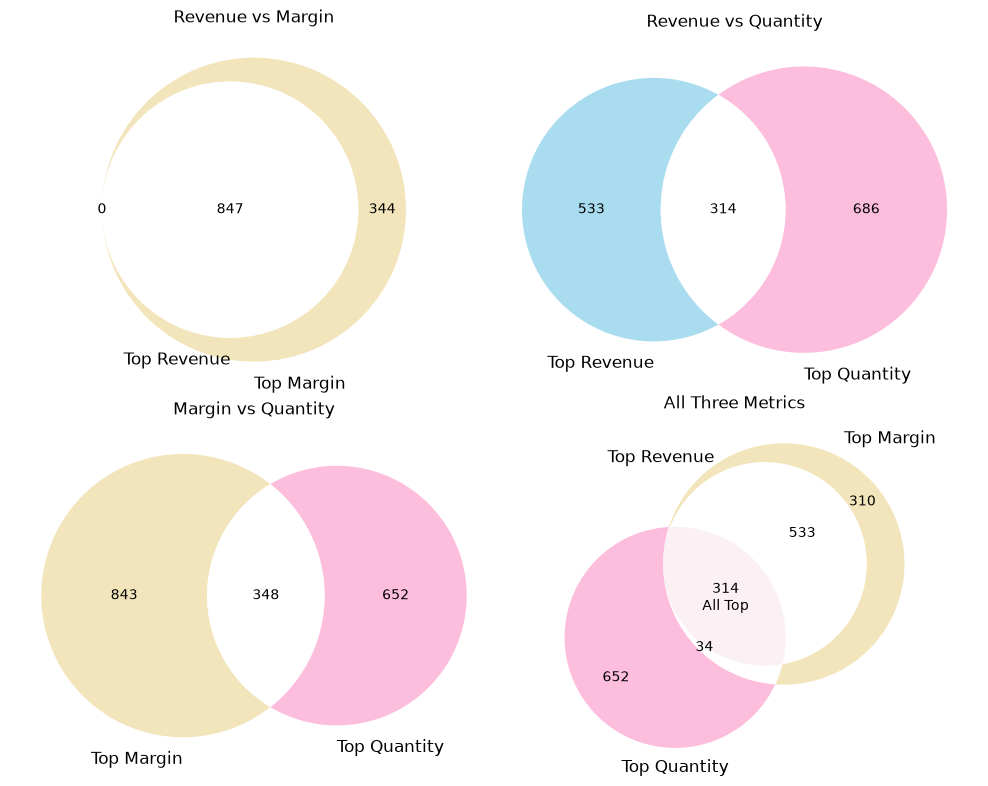

In [11]:
item_col = "item"
set1 = set(top_revenue[item_col]) 
set2 = set(top_margin[item_col])
set3 = set(top_quantity[item_col])

fig, axes = plt.subplots(2, 2, figsize=(10,8))

venn2([set1,set2], set_labels=("Top Revenue", "Top Margin"), ax=axes[0,0], set_colors=("skyblue", "#EEDA9F"), alpha = 0.7)
axes[0,0].set_title("Revenue vs Margin")

venn2([set1, set3], set_labels=("Top Revenue", "Top Quantity"), ax=axes[0,1], set_colors=("skyblue", "#fda1cf"), alpha = 0.7)
axes[0,1].set_title("Revenue vs Quantity")

venn2([set2, set3], set_labels=("Top Margin", "Top Quantity"), ax=axes[1,0], set_colors=("#EEDA9F", "#fda1cf"), alpha = 0.7 )
axes[1,0].set_title("Margin vs Quantity")

v3 = venn3([set1,set2, set3], set_labels=("Top Revenue", "Top Margin", "Top Quantity"), ax=axes[1,1], set_colors=("skyblue", "#EEDA9F", "#fda1cf"), alpha = 0.7)
axes[1,1].set_title("All Three Metrics")
label = v3.get_label_by_id('111')
org = label.get_text()
label.set_text(f"{org}\nAll Top")
plt.tight_layout()
plt.show()